# ============================================================
# PHARMALENS AI
# NOTEBOOK 03 — MOLECULE INTELLIGENCE
# ============================================================
#
# Objective:
# Build molecule-level pharmaceutical market intelligence
# from monthly Egypt pharmaceutical sales data (2021–2025).
#
# Main analyses:
# 1. Molecule Market Size
# 2. Molecule Market Share
# 3. Molecule Growth
# 4. Molecule CAGR
# 5. Molecule Competitive Concentration (HHI)
# 6. Brand Competition within Molecules
# 7. Price Intelligence
# 8. Molecule Lifecycle
# 9. Molecule Opportunity Scoring
# 10. Strategic Molecule Segmentation
# 11. Molecule-Level Executive Dashboard
#
# IMPORTANT:
# The provided data dictionary does not explicitly contain
# an Active Ingredient / Molecule column.
#
# The notebook therefore:
# - Uses Active Ingredient / Molecule if available.
# - Otherwise creates a "Molecule Proxy" from Brand Name.
#
# A true molecule-level analysis requires a validated
# Active Ingredient mapping.
# ============================================================

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [2]:
import numpy as np

pd.set_option ("display.max_columns" ,None)

In [3]:
df=  pd.read_excel ("IMS (2021-2025).xlsx")

In [ ]:
# ============================================================
# 2. LOAD DATA
# ============================================================



try:
    df
    print("Existing DataFrame 'df' detected.")
    
except NameError:
    
    # Change this path only if needed
    DATA_PATH = "pharma_sales.csv"
    
    df = pd.read_csv(DATA_PATH)
    
    print(f"Data loaded from: {DATA_PATH}")

print("Shape:", df.shape)

display(df.head())

In [4]:
df = df.rename(columns={
    "Sector": "Distribution Channel",
    "ATC4": "Therapeutic Class",
    "Corporation": "Manufacturer",
    "Product": "Brand Name",
    "Pack": "Pack Size",
    "Launch Date": "Product Launch",
    "Strength": "Drug Strength",
    "Retail Price": "Selling Price",
    "NFC3": "Market Category",
    "Period": "Month",
    "Calendar Year": "Year",
    "Units": "Sales Units",
    "LC Value": "Sales Value"
})

In [5]:
# ============================================================
# 3. DATA DICTIONARY VALIDATION
# ============================================================

EXPECTED_COLUMNS = [
    "Distribution Channel",
    "Therapeutic Class",
    "Manufacturer",
    "Brand Name",
    "Pack Size",
    "Product Launch",
    "Drug Strength",
    "Selling Price",
    "Market Category",
    "Month",
    "Year",
    "Sales Units",
    "Sales Value"
]

missing_columns = [
    col for col in EXPECTED_COLUMNS
    if col not in df.columns
]

extra_columns = [
    col for col in df.columns
    if col not in EXPECTED_COLUMNS
]

print("Expected columns:")
print(EXPECTED_COLUMNS)

print("\nMissing columns:")
print(missing_columns)

print("\nAdditional columns:")
print(extra_columns)

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("\nColumn validation PASSED.")

Expected columns:
['Distribution Channel', 'Therapeutic Class', 'Manufacturer', 'Brand Name', 'Pack Size', 'Product Launch', 'Drug Strength', 'Selling Price', 'Market Category', 'Month', 'Year', 'Sales Units', 'Sales Value']

Missing columns:
[]

Additional columns:
[]

Column validation PASSED.


In [6]:
# ============================================================
# 4. BASIC DATA CLEANING
# ============================================================

df = df.copy()

# Remove completely empty rows
df = df.dropna(how="all")

# Standardize text columns
TEXT_COLUMNS = [
    "Distribution Channel",
    "Therapeutic Class",
    "Manufacturer",
    "Brand Name",
    "Pack Size",
    "Drug Strength",
    "Market Category"
]

for col in TEXT_COLUMNS:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .replace({
            "nan": np.nan,
            "None": np.nan,
            "": np.nan
        })
    )

# Convert numeric columns
NUMERIC_COLUMNS = [
    "Selling Price",
    "Sales Units",
    "Sales Value",
    "Year"
]

for col in NUMERIC_COLUMNS:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# Convert dates
df["Month"] = pd.to_datetime(
    df["Month"],
    errors="coerce"
)

df["Product Launch"] = pd.to_datetime(
    df["Product Launch"],
    errors="coerce"
)

print("Cleaning completed.")
print("Shape:", df.shape)

Cleaning completed.
Shape: (909922, 13)


In [7]:
# ============================================================
# 5. SALES DATA QUALITY CHECK
# ============================================================

print("Missing values:")
display(
    df[
        EXPECTED_COLUMNS
    ].isna().sum().sort_values(ascending=False)
)

# Keep commercially meaningful records
df = df[
    (df["Sales Units"].fillna(0) >= 0) &
    (df["Sales Value"].fillna(0) >= 0)
].copy()

print("\nFinal analytical dataset:")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Missing values:


Product Launch          9335
Distribution Channel       0
Therapeutic Class          0
Manufacturer               0
Brand Name                 0
Pack Size                  0
Drug Strength              0
Selling Price              0
Market Category            0
Month                      0
Year                       0
Sales Units                0
Sales Value                0
dtype: int64


Final analytical dataset:
Rows: 909922
Columns: 13


In [8]:
# ============================================================
# 6. TIME FEATURES
# ============================================================

# Create monthly reporting period
df["Reporting Month"] = df["Month"]

# Year from Month where possible
df["Analysis Year"] = df["Month"].dt.year

df["Analysis Year"] = df["Analysis Year"].fillna(
    df["Year"]
)

df["Analysis Year"] = df["Analysis Year"].astype("Int64")

# Sort chronologically
df = df.sort_values(
    ["Analysis Year", "Month"]
).reset_index(drop=True)

print(
    "Analysis period:",
    df["Analysis Year"].min(),
    "to",
    df["Analysis Year"].max()
)

Analysis period: 2021 to 2025


In [9]:
# ============================================================
# 7. MOLECULE IDENTIFICATION
# ============================================================

# Search for a true molecule / active ingredient column

possible_molecule_columns = [
    "Active Ingredient",
    "Active Ingredient Name",
    "Molecule",
    "Molecule Name",
    "Generic Name"
]

available_molecule_columns = [
    col for col in possible_molecule_columns
    if col in df.columns
]

if available_molecule_columns:
    
    MOLECULE_SOURCE = available_molecule_columns[0]
    
    df["Molecule"] = (
        df[MOLECULE_SOURCE]
        .astype(str)
        .str.strip()
    )
    
    MOLECULE_MODE = "TRUE MOLECULE"

else:
    
    # IMPORTANT:
    # No active ingredient column exists in the provided
    # data dictionary.
    #
    # Brand Name is used only as a temporary analytical proxy.
    
    df["Molecule"] = (
        df["Brand Name"]
        .astype(str)
        .str.strip()
    )
    
    MOLECULE_SOURCE = "Brand Name"
    MOLECULE_MODE = "MOLECULE PROXY"

print("Molecule source:", MOLECULE_SOURCE)
print("Analysis mode:", MOLECULE_MODE)

if MOLECULE_MODE == "MOLECULE PROXY":
    print(
        "\nWARNING:"
        "\nNo Active Ingredient / Molecule column was found."
        "\nCurrent molecule analysis uses Brand Name as a proxy."
        "\nFor production use, replace this with validated"
        "\nActive Ingredient mapping."
    )

Molecule source: Brand Name
Analysis mode: MOLECULE PROXY

No Active Ingredient / Molecule column was found.
Current molecule analysis uses Brand Name as a proxy.
For production use, replace this with validated
Active Ingredient mapping.


In [10]:
# ============================================================
# 8. MOLECULE MARKET OVERVIEW
# ============================================================

molecule_overview = (
    df.groupby("Molecule")
    .agg(
        Sales_Value=("Sales Value", "sum"),
        Sales_Units=("Sales Units", "sum"),
        Brands=("Brand Name", "nunique"),
        Manufacturers=("Manufacturer", "nunique"),
        Therapeutic_Classes=("Therapeutic Class", "nunique")
    )
    .reset_index()
)

molecule_overview = molecule_overview.sort_values(
    "Sales_Value",
    ascending=False
).reset_index(drop=True)

print("Number of molecules:", len(molecule_overview))

display(
    molecule_overview.head(20)
)

Number of molecules: 9958


,Molecule,Sales_Value,Sales_Units,Brands,Manufacturers,Therapeutic_Classes
0,ZURCAL,"7,804,094,586.89","99,665,626.50",1,1,1
1,AUGMENTIN,"6,813,282,544.76","56,429,367.60",1,1,1
2,CONTROLOC,"6,360,947,599.02","52,485,160.21",1,1,1
3,PANADOL,"6,048,820,037.50","147,806,292.92",1,1,1
4,CLEXANE,"5,555,901,483.87","27,166,033.86",1,1,1
5,GABIMASH,"5,308,933,869.09","38,028,118.12",1,1,1
6,BRUFEN,"5,189,705,575.97","123,496,878.87",1,1,1
7,HIBIOTIC,"5,093,675,168.40","57,249,303.60",1,1,1
8,CONVENTIN,"4,798,666,909.04","51,905,119.55",1,1,1
9,ALPHINTERN,"4,095,526,662.18","71,326,336.13",1,1,1


In [11]:
# ============================================================
# 9. MOLECULE MARKET SHARE
# ============================================================

total_market_value = df["Sales Value"].sum()

molecule_overview["Market Share %"] = (
    molecule_overview["Sales_Value"]
    / total_market_value
    * 100
)

molecule_overview["Cumulative Share %"] = (
    molecule_overview["Market Share %"]
    .cumsum()
)

display(
    molecule_overview.head(20)
)

,Molecule,Sales_Value,Sales_Units,Brands,Manufacturers,Therapeutic_Classes,Market Share %,Cumulative Share %
0,ZURCAL,"7,804,094,586.89","99,665,626.50",1,1,1,0.88,0.88
1,AUGMENTIN,"6,813,282,544.76","56,429,367.60",1,1,1,0.77,1.66
2,CONTROLOC,"6,360,947,599.02","52,485,160.21",1,1,1,0.72,2.38
3,PANADOL,"6,048,820,037.50","147,806,292.92",1,1,1,0.69,3.06
4,CLEXANE,"5,555,901,483.87","27,166,033.86",1,1,1,0.63,3.69
5,GABIMASH,"5,308,933,869.09","38,028,118.12",1,1,1,0.60,4.29
6,BRUFEN,"5,189,705,575.97","123,496,878.87",1,1,1,0.59,4.88
7,HIBIOTIC,"5,093,675,168.40","57,249,303.60",1,1,1,0.58,5.46
8,CONVENTIN,"4,798,666,909.04","51,905,119.55",1,1,1,0.54,6.00
9,ALPHINTERN,"4,095,526,662.18","71,326,336.13",1,1,1,0.46,6.46


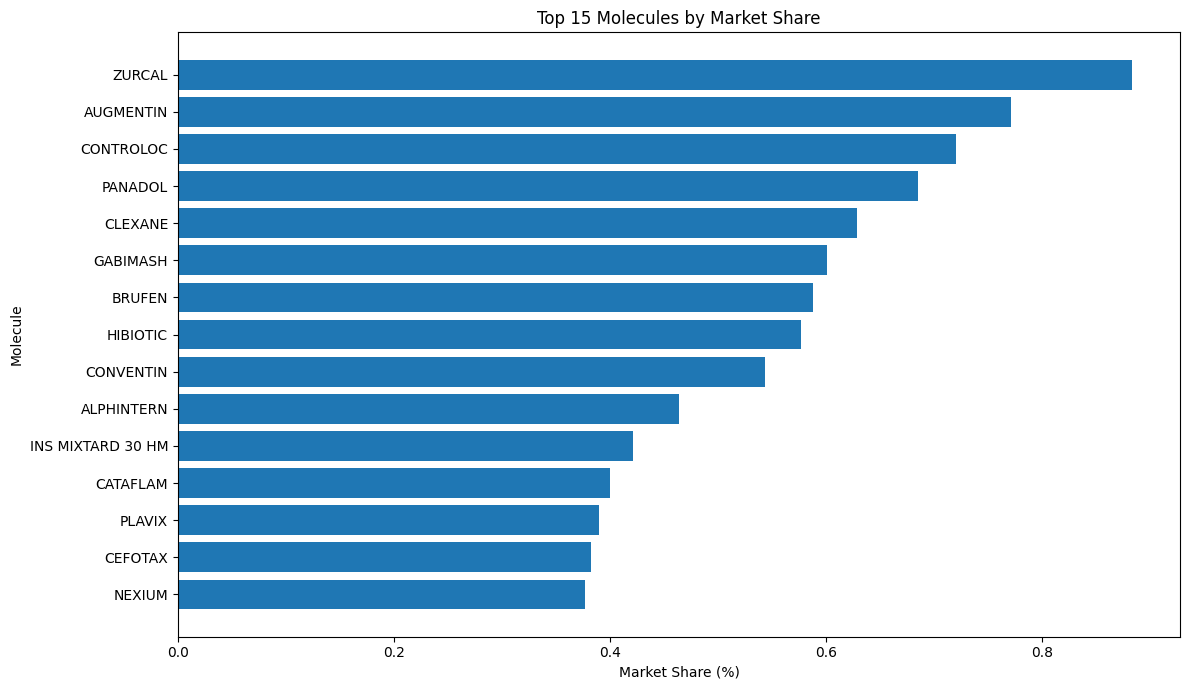

In [12]:
# ============================================================
# 10. TOP MOLECULES BY MARKET SHARE
# ============================================================

top_molecules = (
    molecule_overview
    .head(15)
    .sort_values("Market Share %")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_molecules["Molecule"],
    top_molecules["Market Share %"]
)

plt.xlabel("Market Share (%)")
plt.ylabel("Molecule")
plt.title(
    "Top 15 Molecules by Market Share"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 11. YEARLY MOLECULE PERFORMANCE
# ============================================================

molecule_yearly = (
    df.groupby(
        ["Molecule", "Analysis Year"],
        dropna=False
    )
    .agg(
        Sales_Value=("Sales Value", "sum"),
        Sales_Units=("Sales Units", "sum"),
        Brands=("Brand Name", "nunique"),
        Manufacturers=("Manufacturer", "nunique")
    )
    .reset_index()
)

display(
    molecule_yearly.head(20)
)

In [ ]:
# ============================================================
# 12. MOLECULE GROWTH ANALYSIS
# ============================================================

yearly_sales = (
    df.groupby("Analysis Year")["Sales Value"]
    .sum()
    .sort_index()
)

available_years = sorted(
    df["Analysis Year"]
    .dropna()
    .unique()
)

if len(available_years) >= 2:

    latest_year = available_years[-1]
    previous_year = available_years[-2]

    latest_sales = (
        df[df["Analysis Year"] == latest_year]
        .groupby("Molecule")["Sales Value"]
        .sum()
    )

    previous_sales = (
        df[df["Analysis Year"] == previous_year]
        .groupby("Molecule")["Sales Value"]
        .sum()
    )

    molecule_growth = pd.DataFrame({
        "Latest Sales": latest_sales,
        "Previous Sales": previous_sales
    }).fillna(0)

    molecule_growth["YoY Growth %"] = np.where(
        molecule_growth["Previous Sales"] > 0,
        (
            molecule_growth["Latest Sales"]
            - molecule_growth["Previous Sales"]
        )
        / molecule_growth["Previous Sales"]
        * 100,
        np.nan
    )

    molecule_growth = (
        molecule_growth
        .reset_index()
        .rename(columns={"index": "Molecule"})
    )

else:
    molecule_growth = pd.DataFrame(
        columns=[
            "Molecule",
            "Latest Sales",
            "Previous Sales",
            "YoY Growth %"
        ]
    )

display(
    molecule_growth
    .sort_values(
        "YoY Growth %",
        ascending=False
    )
    .head(20)
)

In [ ]:
# ============================================================
# 13. MOLECULE CAGR
# ============================================================

annual_molecule = (
    df.groupby(
        ["Molecule", "Analysis Year"]
    )["Sales Value"]
    .sum()
    .reset_index()
)

first_year = int(
    annual_molecule["Analysis Year"].min()
)

last_year = int(
    annual_molecule["Analysis Year"].max()
)

start_sales = (
    annual_molecule[
        annual_molecule["Analysis Year"] == first_year
    ]
    .set_index("Molecule")["Sales Value"]
)

end_sales = (
    annual_molecule[
        annual_molecule["Analysis Year"] == last_year
    ]
    .set_index("Molecule")["Sales Value"]
)

molecule_cagr = pd.DataFrame({
    "Start Sales": start_sales,
    "End Sales": end_sales
}).fillna(0)

years = last_year - first_year

if years > 0:

    molecule_cagr["CAGR %"] = np.where(
        (molecule_cagr["Start Sales"] > 0) &
        (molecule_cagr["End Sales"] > 0),
        (
            (
                molecule_cagr["End Sales"]
                / molecule_cagr["Start Sales"]
            )
            ** (1 / years)
            - 1
        )
        * 100,
        np.nan
    )

else:
    molecule_cagr["CAGR %"] = np.nan

molecule_cagr = (
    molecule_cagr
    .reset_index()
    .rename(columns={"index": "Molecule"})
)

display(
    molecule_cagr
    .sort_values("CAGR %", ascending=False)
    .head(20)
)

In [ ]:
# ============================================================
# 14. MOLECULE COMPETITIVE CONCENTRATION — HHI
# ============================================================

# HHI measures manufacturer concentration inside each molecule.
#
# HHI interpretation:
# < 1,500      = Competitive
# 1,500–2,500  = Moderately concentrated
# > 2,500      = Highly concentrated

molecule_manufacturer_sales = (
    df.groupby(
        ["Molecule", "Manufacturer"]
    )["Sales Value"]
    .sum()
    .reset_index()
)

molecule_manufacturer_sales["Manufacturer Share %"] = (
    molecule_manufacturer_sales
    .groupby("Molecule")["Sales Value"]
    .transform(
        lambda x: x / x.sum() * 100
    )
)

molecule_manufacturer_sales["Share Squared"] = (
    molecule_manufacturer_sales["Manufacturer Share %"] ** 2
)

molecule_hhi = (
    molecule_manufacturer_sales
    .groupby("Molecule")
    .agg(
        HHI=("Share Squared", "sum"),
        Manufacturers=("Manufacturer", "nunique")
    )
    .reset_index()
)

def classify_hhi(hhi):
    
    if hhi < 1500:
        return "Competitive"
    
    elif hhi < 2500:
        return "Moderately Concentrated"
    
    else:
        return "Highly Concentrated"

molecule_hhi["Concentration"] = (
    molecule_hhi["HHI"]
    .apply(classify_hhi)
)

display(
    molecule_hhi
    .sort_values("HHI", ascending=False)
    .head(20)
)

In [ ]:
# ============================================================
# 15. MOLECULE LEADERSHIP
# ============================================================

manufacturer_molecule = (
    df.groupby(
        ["Molecule", "Manufacturer"]
    )["Sales Value"]
    .sum()
    .reset_index()
)

manufacturer_molecule["Manufacturer Share %"] = (
    manufacturer_molecule
    .groupby("Molecule")["Sales Value"]
    .transform(
        lambda x: x / x.sum() * 100
    )
)

leader_idx = (
    manufacturer_molecule
    .groupby("Molecule")["Sales Value"]
    .idxmax()
)

molecule_leaders = (
    manufacturer_molecule
    .loc[leader_idx]
    .reset_index(drop=True)
)

molecule_leaders = molecule_leaders.rename(
    columns={
        "Manufacturer": "Leading Manufacturer",
        "Sales Value": "Leader Sales",
        "Manufacturer Share %": "Leader Share %"
    }
)

display(
    molecule_leaders.head(20)
)

In [ ]:
# ============================================================
# 16. BRAND COMPETITION WITHIN MOLECULES
# ============================================================

molecule_competition = (
    df.groupby("Molecule")
    .agg(
        Number_of_Brands=("Brand Name", "nunique"),
        Number_of_Manufacturers=("Manufacturer", "nunique"),
        Number_of_Therapeutic_Classes=(
            "Therapeutic Class",
            "nunique"
        )
    )
    .reset_index()
)

display(
    molecule_competition
    .sort_values(
        "Number_of_Brands",
        ascending=False
    )
    .head(20)
)

In [ ]:
# ============================================================
# 17. MOLECULE PRICE INTELLIGENCE
# ============================================================

molecule_price = (
    df.groupby("Molecule")
    .agg(
        Average_Price=("Selling Price", "mean"),
        Median_Price=("Selling Price", "median"),
        Minimum_Price=("Selling Price", "min"),
        Maximum_Price=("Selling Price", "max"),
        Price_Std=("Selling Price", "std")
    )
    .reset_index()
)

molecule_price["Price Range"] = (
    molecule_price["Maximum_Price"]
    - molecule_price["Minimum_Price"]
)

display(
    molecule_price
    .sort_values(
        "Average_Price",
        ascending=False
    )
    .head(20)
)

In [ ]:
# ============================================================
# 18. PRICE COMPETITION
# ============================================================

molecule_price["Price CV %"] = np.where(
    molecule_price["Average_Price"] > 0,
    molecule_price["Price_Std"]
    / molecule_price["Average_Price"]
    * 100,
    np.nan
)

molecule_price["Price Competition"] = pd.cut(
    molecule_price["Price CV %"],
    bins=[-np.inf, 10, 25, np.inf],
    labels=[
        "Low Price Variation",
        "Moderate Price Variation",
        "High Price Variation"
    ]
)

display(
    molecule_price
    .sort_values(
        "Price CV %",
        ascending=False
    )
    .head(20)
)

In [ ]:
# ============================================================
# 19. MOLECULE LIFECYCLE
# ============================================================

molecule_monthly = (
    df.groupby(
        ["Molecule", "Month"]
    )["Sales Value"]
    .sum()
    .reset_index()
    .sort_values(
        ["Molecule", "Month"]
    )
)

# First observed month
first_observed = (
    molecule_monthly
    .groupby("Molecule")["Month"]
    .min()
    .rename("First Observed Month")
)

last_observed = (
    molecule_monthly
    .groupby("Molecule")["Month"]
    .max()
    .rename("Last Observed Month")
)

molecule_lifecycle = pd.concat(
    [
        first_observed,
        last_observed
    ],
    axis=1
).reset_index()

# Duration in months
molecule_lifecycle["Observed Months"] = (
    (
        molecule_lifecycle["Last Observed Month"]
        - molecule_lifecycle["First Observed Month"]
    )
    / np.timedelta64(1, "M")
).round()

display(
    molecule_lifecycle.head(20)
)

In [ ]:
# ============================================================
# 20. MOLECULE LIFECYCLE CLASSIFICATION
# ============================================================

latest_month = df["Month"].max()

molecule_lifecycle["Months Since Last Sale"] = (
    (
        latest_month
        - molecule_lifecycle["Last Observed Month"]
    )
    / np.timedelta64(1, "M")
).round()

def lifecycle_stage(row):

    months_active = row["Observed Months"]
    inactivity = row["Months Since Last Sale"]

    if pd.isna(inactivity):
        return "Unknown"

    if inactivity > 12:
        return "Declining / Dormant"

    if months_active <= 12:
        return "Emerging"

    if months_active <= 36:
        return "Growth"

    return "Mature"

molecule_lifecycle["Lifecycle Stage"] = (
    molecule_lifecycle.apply(
        lifecycle_stage,
        axis=1
    )
)

display(
    molecule_lifecycle[
        [
            "Molecule",
            "Observed Months",
            "Months Since Last Sale",
            "Lifecycle Stage"
        ]
    ].head(20)
)

In [ ]:
# ============================================================
# 21. MOLECULE LAUNCH INTELLIGENCE
# ============================================================

launch_data = df.dropna(
    subset=["Product Launch"]
).copy()

launch_data["Launch Year"] = (
    launch_data["Product Launch"]
    .dt.year
)

molecule_launch = (
    launch_data.groupby("Molecule")
    .agg(
        First_Launch_Date=("Product Launch", "min"),
        Brands_Launched=("Brand Name", "nunique"),
        Manufacturers_Launched=("Manufacturer", "nunique")
    )
    .reset_index()
)

molecule_launch["Launch Year"] = (
    molecule_launch["First_Launch_Date"]
    .dt.year
)

display(
    molecule_launch
    .sort_values(
        "First_Launch_Date"
    )
    .head(20)
)

In [ ]:
# ============================================================
# 22. BUILD MASTER MOLECULE INTELLIGENCE TABLE
# ============================================================

molecule_intelligence = molecule_overview.copy()

merge_tables = [
    molecule_growth,
    molecule_cagr,
    molecule_hhi,
    molecule_leaders,
    molecule_competition,
    molecule_price,
    molecule_lifecycle,
    molecule_launch
]

for table in merge_tables:
    
    molecule_intelligence = molecule_intelligence.merge(
        table,
        on="Molecule",
        how="left"
    )

# Remove duplicated columns where necessary
molecule_intelligence = (
    molecule_intelligence
    .loc[
        :,
        ~molecule_intelligence.columns.duplicated()
    ]
)

print(
    "Molecule Intelligence shape:",
    molecule_intelligence.shape
)

display(
    molecule_intelligence.head(20)
)

In [ ]:
# ============================================================
# 23. STRATEGIC METRIC NORMALIZATION
# ============================================================

def minmax(series):

    series = series.replace(
        [np.inf, -np.inf],
        np.nan
    )

    min_value = series.min()
    max_value = series.max()

    if pd.isna(min_value) or pd.isna(max_value):
        return pd.Series(
            0,
            index=series.index
        )

    if max_value == min_value:
        return pd.Series(
            50,
            index=series.index
        )

    return (
        (series - min_value)
        / (max_value - min_value)
        * 100
    )

molecule_intelligence["Market Strength Score"] = (
    minmax(
        molecule_intelligence["Sales_Value"]
    )
)

molecule_intelligence["Growth Score"] = (
    minmax(
        molecule_intelligence["YoY Growth %"]
    )
)

molecule_intelligence["CAGR Score"] = (
    minmax(
        molecule_intelligence["CAGR %"]
    )
)

molecule_intelligence["Competition Score"] = (
    100
    - minmax(
        molecule_intelligence["HHI"]
    )
)

molecule_intelligence["Brand Breadth Score"] = (
    minmax(
        molecule_intelligence["Brands"]
    )
)

In [ ]:
# ============================================================
# 24. MOLECULE OPPORTUNITY SCORE
# ============================================================

molecule_intelligence["Opportunity Score"] = (
    molecule_intelligence["Market Strength Score"] * 0.25
    +
    molecule_intelligence["Growth Score"] * 0.25
    +
    molecule_intelligence["CAGR Score"] * 0.20
    +
    molecule_intelligence["Competition Score"] * 0.20
    +
    molecule_intelligence["Brand Breadth Score"] * 0.10
)

molecule_intelligence["Opportunity Score"] = (
    molecule_intelligence["Opportunity Score"]
    .clip(0, 100)
)

display(
    molecule_intelligence[
        [
            "Molecule",
            "Sales_Value",
            "Market Share %",
            "YoY Growth %",
            "CAGR %",
            "HHI",
            "Opportunity Score"
        ]
    ]
    .sort_values(
        "Opportunity Score",
        ascending=False
    )
    .head(25)
)

In [ ]:
# ============================================================
# 25. STRATEGIC MOLECULE SEGMENTATION
# ============================================================

def molecule_strategy(row):

    score = row["Opportunity Score"]
    growth = row["YoY Growth %"]
    share = row["Market Share %"]
    hhi = row["HHI"]

    if (
        score >= 75
        and growth >= 0
    ):
        return "High-Priority Opportunity"

    elif (
        share >= 5
        and growth >= 0
    ):
        return "Defend & Invest"

    elif (
        growth >= 10
        and share < 5
    ):
        return "Growth Challenger"

    elif (
        hhi >= 2500
        and growth >= 0
    ):
        return "Concentrated Opportunity"

    elif growth < 0:
        return "Monitor / Declining"

    else:
        return "Selective Investment"

molecule_intelligence["Strategic Segment"] = (
    molecule_intelligence.apply(
        molecule_strategy,
        axis=1
    )
)

display(
    molecule_intelligence[
        [
            "Molecule",
            "Opportunity Score",
            "Strategic Segment"
        ]
    ]
    .sort_values(
        "Opportunity Score",
        ascending=False
    )
    .head(30)
)

In [ ]:
# ============================================================
# 26. STRATEGIC SEGMENT DISTRIBUTION
# ============================================================

segment_counts = (
    molecule_intelligence["Strategic Segment"]
    .value_counts()
)

display(segment_counts)

plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.xlabel("Strategic Segment")
plt.ylabel("Number of Molecules")
plt.title(
    "Molecule Strategic Segmentation"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 27. TOP MOLECULE OPPORTUNITIES
# ============================================================

top_opportunities = (
    molecule_intelligence[
        molecule_intelligence["Opportunity Score"] >= 75
    ]
    .sort_values(
        "Opportunity Score",
        ascending=False
    )
)

display(
    top_opportunities[
        [
            "Molecule",
            "Sales_Value",
            "Market Share %",
            "YoY Growth %",
            "CAGR %",
            "HHI",
            "Number_of_Brands",
            "Number_of_Manufacturers",
            "Opportunity Score",
            "Strategic Segment"
        ]
    ].head(30)
)

In [ ]:
# ============================================================
# 28. HIGH-GROWTH MOLECULES
# ============================================================

high_growth_molecules = (
    molecule_intelligence[
        molecule_intelligence["YoY Growth %"] >= 10
    ]
    .sort_values(
        "YoY Growth %",
        ascending=False
    )
)

display(
    high_growth_molecules[
        [
            "Molecule",
            "Sales_Value",
            "Market Share %",
            "YoY Growth %",
            "CAGR %",
            "Opportunity Score",
            "Strategic Segment"
        ]
    ].head(30)
)

In [ ]:
# ============================================================
# 29. MARKET-DOMINANT MOLECULES
# ============================================================

dominant_molecules = (
    molecule_intelligence[
        molecule_intelligence["Market Share %"] >= 1
    ]
    .sort_values(
        "Market Share %",
        ascending=False
    )
)

display(
    dominant_molecules[
        [
            "Molecule",
            "Sales_Value",
            "Market Share %",
            "YoY Growth %",
            "HHI",
            "Leading Manufacturer",
            "Leader Share %",
            "Strategic Segment"
        ]
    ].head(30)
)

In [ ]:
# ============================================================
# 30. MOLECULE MARKET SHARE vs GROWTH
# ============================================================

plot_data = molecule_intelligence.dropna(
    subset=[
        "Market Share %",
        "YoY Growth %"
    ]
)

plt.figure(figsize=(12, 8))

plt.scatter(
    plot_data["Market Share %"],
    plot_data["YoY Growth %"],
    s=40,
    alpha=0.6
)

plt.axhline(
    0,
    linestyle="--"
)

plt.axvline(
    plot_data["Market Share %"].median(),
    linestyle="--"
)

plt.xlabel("Market Share (%)")
plt.ylabel("YoY Growth (%)")
plt.title(
    "Molecule Market Share vs Growth"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 31. TOP MOLECULES BY GROWTH
# ============================================================

growth_plot = (
    molecule_intelligence
    .dropna(subset=["YoY Growth %"])
    .sort_values(
        "YoY Growth %",
        ascending=False
    )
    .head(15)
    .sort_values(
        "YoY Growth %"
    )
)

plt.figure(figsize=(12, 7))

plt.barh(
    growth_plot["Molecule"],
    growth_plot["YoY Growth %"]
)

plt.xlabel("YoY Growth (%)")
plt.ylabel("Molecule")
plt.title(
    "Top 15 Molecules by YoY Growth"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 32. MOLECULE CONCENTRATION ANALYSIS
# ============================================================

hhi_plot = (
    molecule_intelligence
    .sort_values(
        "HHI",
        ascending=False
    )
    .head(15)
    .sort_values("HHI")
)

plt.figure(figsize=(12, 7))

plt.barh(
    hhi_plot["Molecule"],
    hhi_plot["HHI"]
)

plt.axvline(
    1500,
    linestyle="--",
    label="1,500"
)

plt.axvline(
    2500,
    linestyle="--",
    label="2,500"
)

plt.xlabel("HHI")
plt.ylabel("Molecule")
plt.title(
    "Top Concentrated Molecules by HHI"
)

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 33. TOP MOLECULE MARKET TREND
# ============================================================

top_10_molecules = (
    molecule_intelligence
    .nlargest(
        10,
        "Sales_Value"
    )["Molecule"]
    .tolist()
)

trend_data = (
    df[
        df["Molecule"].isin(
            top_10_molecules
        )
    ]
    .groupby(
        ["Month", "Molecule"]
    )["Sales Value"]
    .sum()
    .reset_index()
)

pivot_trend = (
    trend_data
    .pivot(
        index="Month",
        columns="Molecule",
        values="Sales Value"
    )
)

plt.figure(figsize=(14, 8))

for molecule in pivot_trend.columns:
    
    plt.plot(
        pivot_trend.index,
        pivot_trend[molecule],
        label=molecule
    )

plt.xlabel("Month")
plt.ylabel("Sales Value")
plt.title(
    "Monthly Sales Trend — Top 10 Molecules"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 34. MOLECULE THERAPEUTIC INTELLIGENCE
# ============================================================

molecule_therapy = (
    df.groupby(
        [
            "Therapeutic Class",
            "Molecule"
        ]
    )
    .agg(
        Sales_Value=("Sales Value", "sum"),
        Sales_Units=("Sales Units", "sum"),
        Brands=("Brand Name", "nunique"),
        Manufacturers=("Manufacturer", "nunique")
    )
    .reset_index()
)

molecule_therapy["Therapeutic Share %"] = (
    molecule_therapy
    .groupby("Therapeutic Class")["Sales_Value"]
    .transform(
        lambda x: x / x.sum() * 100
    )
)

display(
    molecule_therapy
    .sort_values(
        "Sales_Value",
        ascending=False
    )
    .head(30)
)

In [ ]:
# ============================================================
# 35. MOLECULE CHANNEL INTELLIGENCE
# ============================================================

molecule_channel = (
    df.groupby(
        [
            "Molecule",
            "Distribution Channel"
        ]
    )
    .agg(
        Sales_Value=("Sales Value", "sum"),
        Sales_Units=("Sales Units", "sum")
    )
    .reset_index()
)

molecule_channel["Channel Share %"] = (
    molecule_channel
    .groupby("Molecule")["Sales_Value"]
    .transform(
        lambda x: x / x.sum() * 100
    )
)

display(
    molecule_channel
    .sort_values(
        "Sales_Value",
        ascending=False
    )
    .head(30)
)

In [ ]:
# ============================================================
# 36. EXECUTIVE MOLECULE INTELLIGENCE TABLE
# ============================================================

executive_molecule_table = molecule_intelligence[
    [
        "Molecule",
        "Sales_Value",
        "Sales_Units",
        "Market Share %",
        "YoY Growth %",
        "CAGR %",
        "Brands",
        "Manufacturers",
        "HHI",
        "Concentration",
        "Leading Manufacturer",
        "Leader Share %",
        "Average_Price",
        "Lifecycle Stage",
        "Opportunity Score",
        "Strategic Segment"
    ]
].copy()

executive_molecule_table = (
    executive_molecule_table
    .sort_values(
        "Opportunity Score",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    executive_molecule_table.head(30)
)

In [ ]:
# ============================================================
# 37. MOLECULE EXECUTIVE KPIs
# ============================================================

total_molecules = (
    molecule_intelligence["Molecule"]
    .nunique()
)

total_molecule_sales = (
    molecule_intelligence["Sales_Value"]
    .sum()
)

top_10_share = (
    molecule_intelligence
    .nlargest(10, "Sales_Value")["Market Share %"]
    .sum()
)

high_growth_count = (
    (molecule_intelligence["YoY Growth %"] >= 10)
    .sum()
)

high_priority_count = (
    (
        molecule_intelligence["Strategic Segment"]
        == "High-Priority Opportunity"
    )
    .sum()
)

highly_concentrated_count = (
    (
        molecule_intelligence["Concentration"]
        == "Highly Concentrated"
    )
    .sum()
)

print("====================================================")
print("MOLECULE EXECUTIVE KPIs")
print("====================================================")

print(f"Total Molecules: {total_molecules:,}")
print(f"Total Molecule Sales: {total_molecule_sales:,.0f}")
print(f"Top 10 Molecule Share: {top_10_share:.2f}%")
print(f"High-Growth Molecules: {high_growth_count:,}")
print(f"High-Priority Opportunities: {high_priority_count:,}")
print(
    f"Highly Concentrated Molecules: "
    f"{highly_concentrated_count:,}"
)

In [ ]:
# ============================================================
# 38. MOLECULE EXECUTIVE DASHBOARD
# ============================================================

fig = plt.figure(figsize=(16, 10))

# ------------------------------------------------------------
# KPI DATA
# ------------------------------------------------------------

kpis = [
    ("Total Molecules", f"{total_molecules:,}"),
    ("Market Sales", f"{total_molecule_sales:,.0f}"),
    ("Top 10 Share", f"{top_10_share:.1f}%"),
    ("High Growth", f"{high_growth_count:,}"),
    ("High Priority", f"{high_priority_count:,}")
]

# ------------------------------------------------------------
# KPI CARDS
# ------------------------------------------------------------

for i, (label, value) in enumerate(kpis):
    
    ax = fig.add_axes([
        0.05 + i * 0.19,
        0.78,
        0.17,
        0.12
    ])
    
    ax.axis("off")
    
    ax.text(
        0.5,
        0.65,
        value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold"
    )
    
    ax.text(
        0.5,
        0.20,
        label,
        ha="center",
        va="center",
        fontsize=11
    )

# ------------------------------------------------------------
# TOP MOLECULES
# ------------------------------------------------------------

ax1 = fig.add_axes([
    0.07,
    0.42,
    0.40,
    0.28
])

dashboard_top = (
    molecule_intelligence
    .nlargest(
        10,
        "Sales_Value"
    )
    .sort_values("Sales_Value")
)

ax1.barh(
    dashboard_top["Molecule"],
    dashboard_top["Market Share %"]
)

ax1.set_title(
    "Top Molecules by Market Share"
)

ax1.set_xlabel(
    "Market Share (%)"
)

# ------------------------------------------------------------
# TOP OPPORTUNITIES
# ------------------------------------------------------------

ax2 = fig.add_axes([
    0.55,
    0.42,
    0.40,
    0.28
])

dashboard_opportunities = (
    molecule_intelligence
    .nlargest(
        10,
        "Opportunity Score"
    )
    .sort_values("Opportunity Score")
)

ax2.barh(
    dashboard_opportunities["Molecule"],
    dashboard_opportunities["Opportunity Score"]
)

ax2.set_title(
    "Top Molecule Opportunities"
)

ax2.set_xlabel(
    "Opportunity Score"
)

# ------------------------------------------------------------
# STRATEGIC SEGMENTS
# ------------------------------------------------------------

ax3 = fig.add_axes([
    0.25,
    0.08,
    0.50,
    0.25
])

segment_plot = (
    molecule_intelligence["Strategic Segment"]
    .value_counts()
)

ax3.bar(
    segment_plot.index,
    segment_plot.values
)

ax3.set_title(
    "Strategic Molecule Segments"
)

ax3.set_ylabel(
    "Number of Molecules"
)

ax3.tick_params(
    axis="x",
    rotation=45
)

plt.suptitle(
    "PharmaLens AI — Molecule Intelligence Dashboard",
    fontsize=18,
    fontweight="bold"
)

plt.show()

In [ ]:
# ============================================================
# 39. AUTOMATED STRATEGIC CONCLUSIONS
# ============================================================

print("=" * 70)
print("PHARMALENS AI — MOLECULE INTELLIGENCE CONCLUSIONS")
print("=" * 70)

# Top molecule
top_molecule = (
    molecule_intelligence
    .nlargest(1, "Sales_Value")
    .iloc[0]
)

print("\n1. MARKET LEADER")
print(
    f"{top_molecule['Molecule']} is the largest molecule "
    f"by sales value with "
    f"{top_molecule['Market Share %']:.2f}% market share."
)

# Growth leader
growth_candidates = molecule_intelligence.dropna(
    subset=["YoY Growth %"]
)

if not growth_candidates.empty:

    growth_leader = (
        growth_candidates
        .nlargest(1, "YoY Growth %")
        .iloc[0]
    )

    print("\n2. GROWTH LEADER")
    print(
        f"{growth_leader['Molecule']} shows the highest "
        f"YoY growth at "
        f"{growth_leader['YoY Growth %']:.2f}%."
    )

# Concentrated market
concentration_candidates = (
    molecule_intelligence
    .dropna(subset=["HHI"])
)

if not concentration_candidates.empty:

    concentration_leader = (
        concentration_candidates
        .nlargest(1, "HHI")
        .iloc[0]
    )

    print("\n3. MOST CONCENTRATED MOLECULE")
    print(
        f"{concentration_leader['Molecule']} has the highest "
        f"manufacturer concentration with HHI = "
        f"{concentration_leader['HHI']:.0f}."
    )

# Opportunity
opportunity_leader = (
    molecule_intelligence
    .nlargest(1, "Opportunity Score")
    .iloc[0]
)

print("\n4. TOP STRATEGIC OPPORTUNITY")
print(
    f"{opportunity_leader['Molecule']} has the highest "
    f"Opportunity Score of "
    f"{opportunity_leader['Opportunity Score']:.1f}."
)

print("\n5. STRATEGIC SEGMENT DISTRIBUTION")

display(
    molecule_intelligence[
        "Strategic Segment"
    ]
    .value_counts()
    .rename_axis("Strategic Segment")
    .reset_index(name="Molecule Count")
)

In [ ]:
# ============================================================
# 40. EXPORT MOLECULE INTELLIGENCE
# ============================================================

OUTPUT_FILE = "PharmaLens_Molecule_Intelligence.xlsx"

with pd.ExcelWriter(
    OUTPUT_FILE,
    engine="openpyxl"
) as writer:

    molecule_intelligence.to_excel(
        writer,
        sheet_name="Molecule Intelligence",
        index=False
    )

    executive_molecule_table.to_excel(
        writer,
        sheet_name="Executive Molecules",
        index=False
    )

    molecule_hhi.to_excel(
        writer,
        sheet_name="Molecule HHI",
        index=False
    )

    molecule_growth.to_excel(
        writer,
        sheet_name="Molecule Growth",
        index=False
    )

    molecule_cagr.to_excel(
        writer,
        sheet_name="Molecule CAGR",
        index=False
    )

    molecule_therapy.to_excel(
        writer,
        sheet_name="Therapeutic Intelligence",
        index=False
    )

    molecule_channel.to_excel(
        writer,
        sheet_name="Channel Intelligence",
        index=False
    )

print(
    f"Export completed: {OUTPUT_FILE}"
)

In [ ]:
# ============================================================
# 41. EXPORT CSV
# ============================================================

CSV_FILE = "PharmaLens_Molecule_Intelligence.csv"

executive_molecule_table.to_csv(
    CSV_FILE,
    index=False
)

print(
    f"CSV export completed: {CSV_FILE}"
)

In [ ]:
# ============================================================
# 42. NOTEBOOK COMPLETION CHECK
# ============================================================

print("=" * 70)
print("PHARMALENS AI — NOTEBOOK 03 COMPLETED")
print("=" * 70)

print("\nCompleted Modules:")
print("✓ Molecule Market Size")
print("✓ Molecule Market Share")
print("✓ Molecule Growth")
print("✓ Molecule CAGR")
print("✓ Molecule HHI")
print("✓ Manufacturer Leadership")
print("✓ Brand Competition")
print("✓ Price Intelligence")
print("✓ Molecule Lifecycle")
print("✓ Launch Intelligence")
print("✓ Therapeutic Intelligence")
print("✓ Channel Intelligence")
print("✓ Opportunity Score")
print("✓ Strategic Segmentation")
print("✓ Executive Molecule Dashboard")
print("✓ Strategic Conclusions")
print("✓ Excel Export")
print("✓ CSV Export")

print("\nMolecule Mode:", MOLECULE_MODE)

if MOLECULE_MODE == "MOLECULE PROXY":
    print("\nIMPORTANT:")
    print(
        "Active Ingredient data is required to convert this "
        "from Molecule Proxy Intelligence into true "
        "Molecule Intelligence."
    )

print("\nNext Notebook:")
print("04_Launch_Success.ipynb")